# 02 – Exploratory Data Analysis (EDA) of Banking77

**Purpose:** Run exploratory data analysis on the preprocessed Banking77 dataset splits, review class frequencies, query lengths, and save summary metrics, tables, and visualization plots.

This notebook demonstrates:
1. Loading preprocessed cached dataset splits.
2. Generating descriptive statistics for text sequence length.
3. Reviewing class label / intent distributions (identifying imbalance or rare classes).
4. Reviewing vocabulary frequencies and top word counts.
5. Saving artifacts to `outputs/eda/` for downstream reporting.

## 0. Environment Setup

Import essential libraries and add repository root to `sys.path`.

In [1]:
import sys
from pathlib import Path

import IPython.display as display
import pandas as pd

REPO_ROOT = Path().resolve().parent
if REPO_ROOT.name != "SupportAI" and (REPO_ROOT / "SupportAI").exists():
    REPO_ROOT = REPO_ROOT / "SupportAI"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root: {REPO_ROOT}")

Repo root: C:\Users\gunav\Downloads\SupportAI


## 1. Load Preprocessed Data Splits

Load train, val, and test splits from the cache using the data layer coordinator function.

In [2]:
from src.data.dataset import load_and_preprocess_dataset

splits = load_and_preprocess_dataset()
train_df = splits["train"]
val_df = splits["val"]
test_df = splits["test"]

print(f"Train records: {len(train_df)}")
print(f"Val records:   {len(val_df)}")
print(f"Test records:  {len(test_df)}")

[07/13/26 20:27:41] INFO     All dataset splits cached locally under:                                              
                             C:\Users\gunav\Downloads\SupportAI\data\customer_support_tickets_v1. Loading...

                    INFO     Loading 'train' split from local cache:                                               
                             C:\Users\gunav\Downloads\SupportAI\data\customer_support_tickets_v1\train.parquet

                    INFO     Loading 'val' split from local cache:                                                 
                             C:\Users\gunav\Downloads\SupportAI\data\customer_support_tickets_v1\val.parquet

                    INFO     Loading 'test' split from local cache:                                                
                             C:\Users\gunav\Downloads\SupportAI\data\customer_support_tickets_v1\test.parquet

Train records: 10458
Val records:   1309
Test records:  1302


## 2. Trigger EDA Generator Programmatically

We can trigger the EDA artifact generator to output standard plots, tables, and JSON reports under `outputs/eda/`.

In [3]:
from src.data.eda import generate_eda_artifacts

summary = generate_eda_artifacts()
print("EDA generation complete! Key statistics:")
print(f"Total dataset rows: {summary['total_rows']}")
print(f"Vocabulary size:    {summary['vocabulary_size']} words")
print(f"Unique intents:     {summary['unique_classes']}")
print(f"Rare intents (<100): {summary['rare_classes_count']}")

[07/13/26 20:27:42] INFO     Starting EDA generation...

                    INFO     All dataset splits cached locally under:                                              
                             C:\Users\gunav\Downloads\SupportAI\data\customer_support_tickets_v1. Loading...

                    INFO     Loading 'train' split from local cache:                                               
                             C:\Users\gunav\Downloads\SupportAI\data\customer_support_tickets_v1\train.parquet

                    INFO     Loading 'val' split from local cache:                                                 
                             C:\Users\gunav\Downloads\SupportAI\data\customer_support_tickets_v1\val.parquet

                    INFO     Loading 'test' split from local cache:                                                
                             C:\Users\gunav\Downloads\SupportAI\data\customer_support_tickets_v1\test.parquet

                    INFO     Saving EDA summary json to:                                                           
                             C:\Users\gunav\Downloads\SupportAI\outputs\eda\summary.json

[07/13/26 20:27:43] INFO     EDA generation completed. Artifacts saved under:                                      
                             C:\Users\gunav\Downloads\SupportAI\outputs\eda

EDA generation complete! Key statistics:
Total dataset rows: 13069
Vocabulary size:    4154 words
Unique intents:     77
Rare intents (<100): 3


## 3. Display Visualization Plots

Let's render the generated figures directly in the notebook.

### A. Sentence Length Histogram

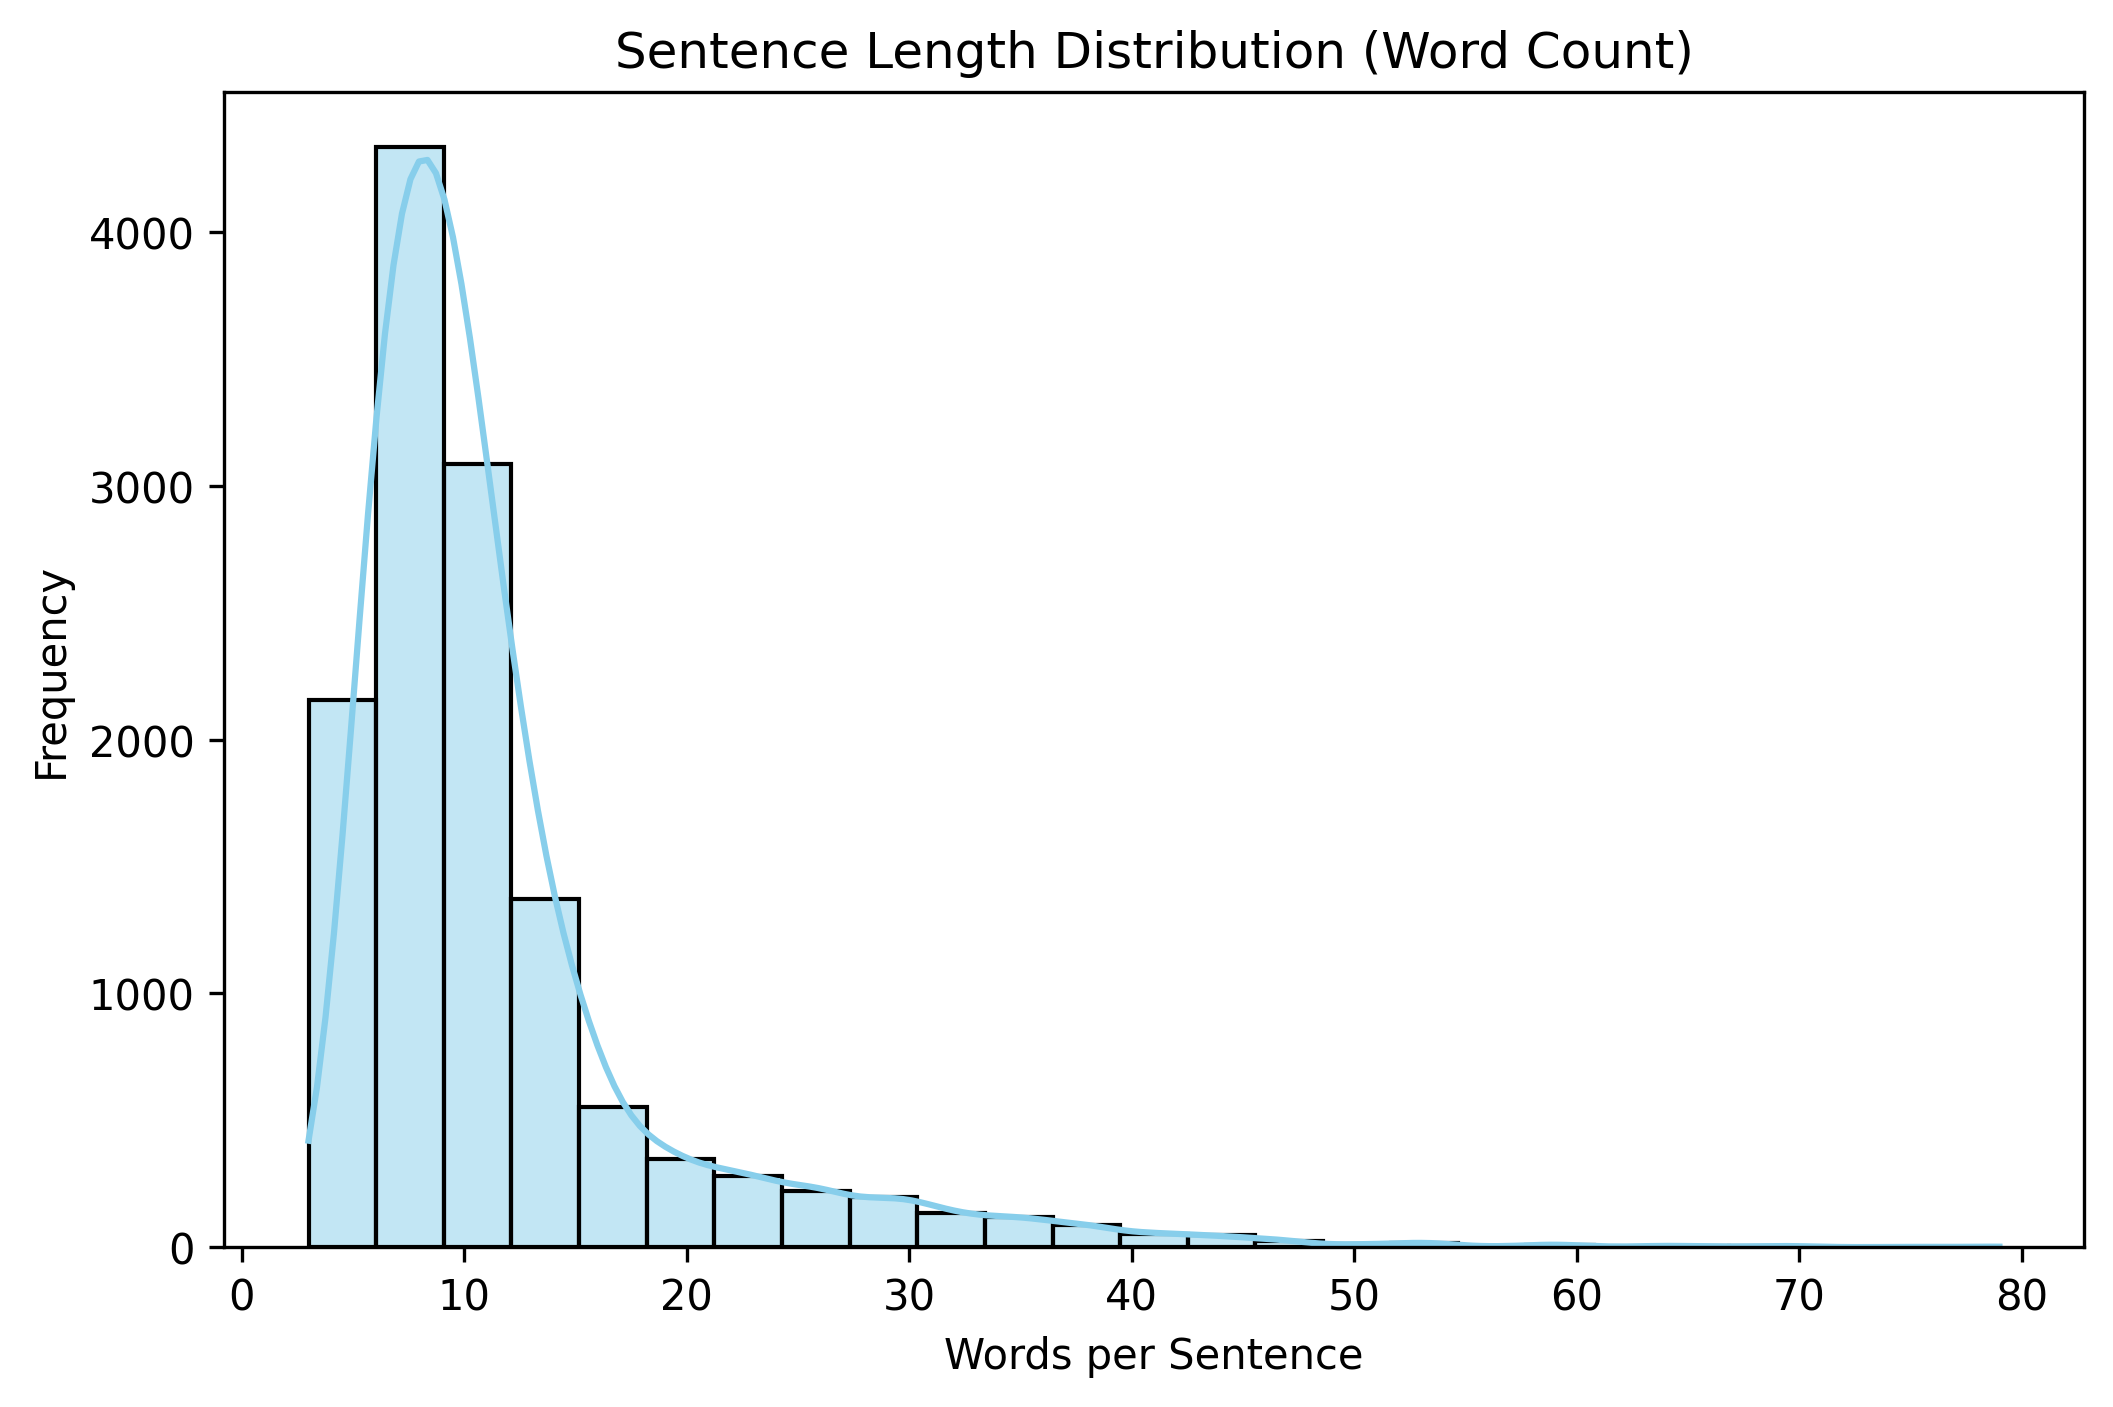

In [4]:
display.Image(filename=str(REPO_ROOT / "outputs" / "eda" / "plots" / "sentence_lengths.png"))

### B. Top 25 Intent Distribution

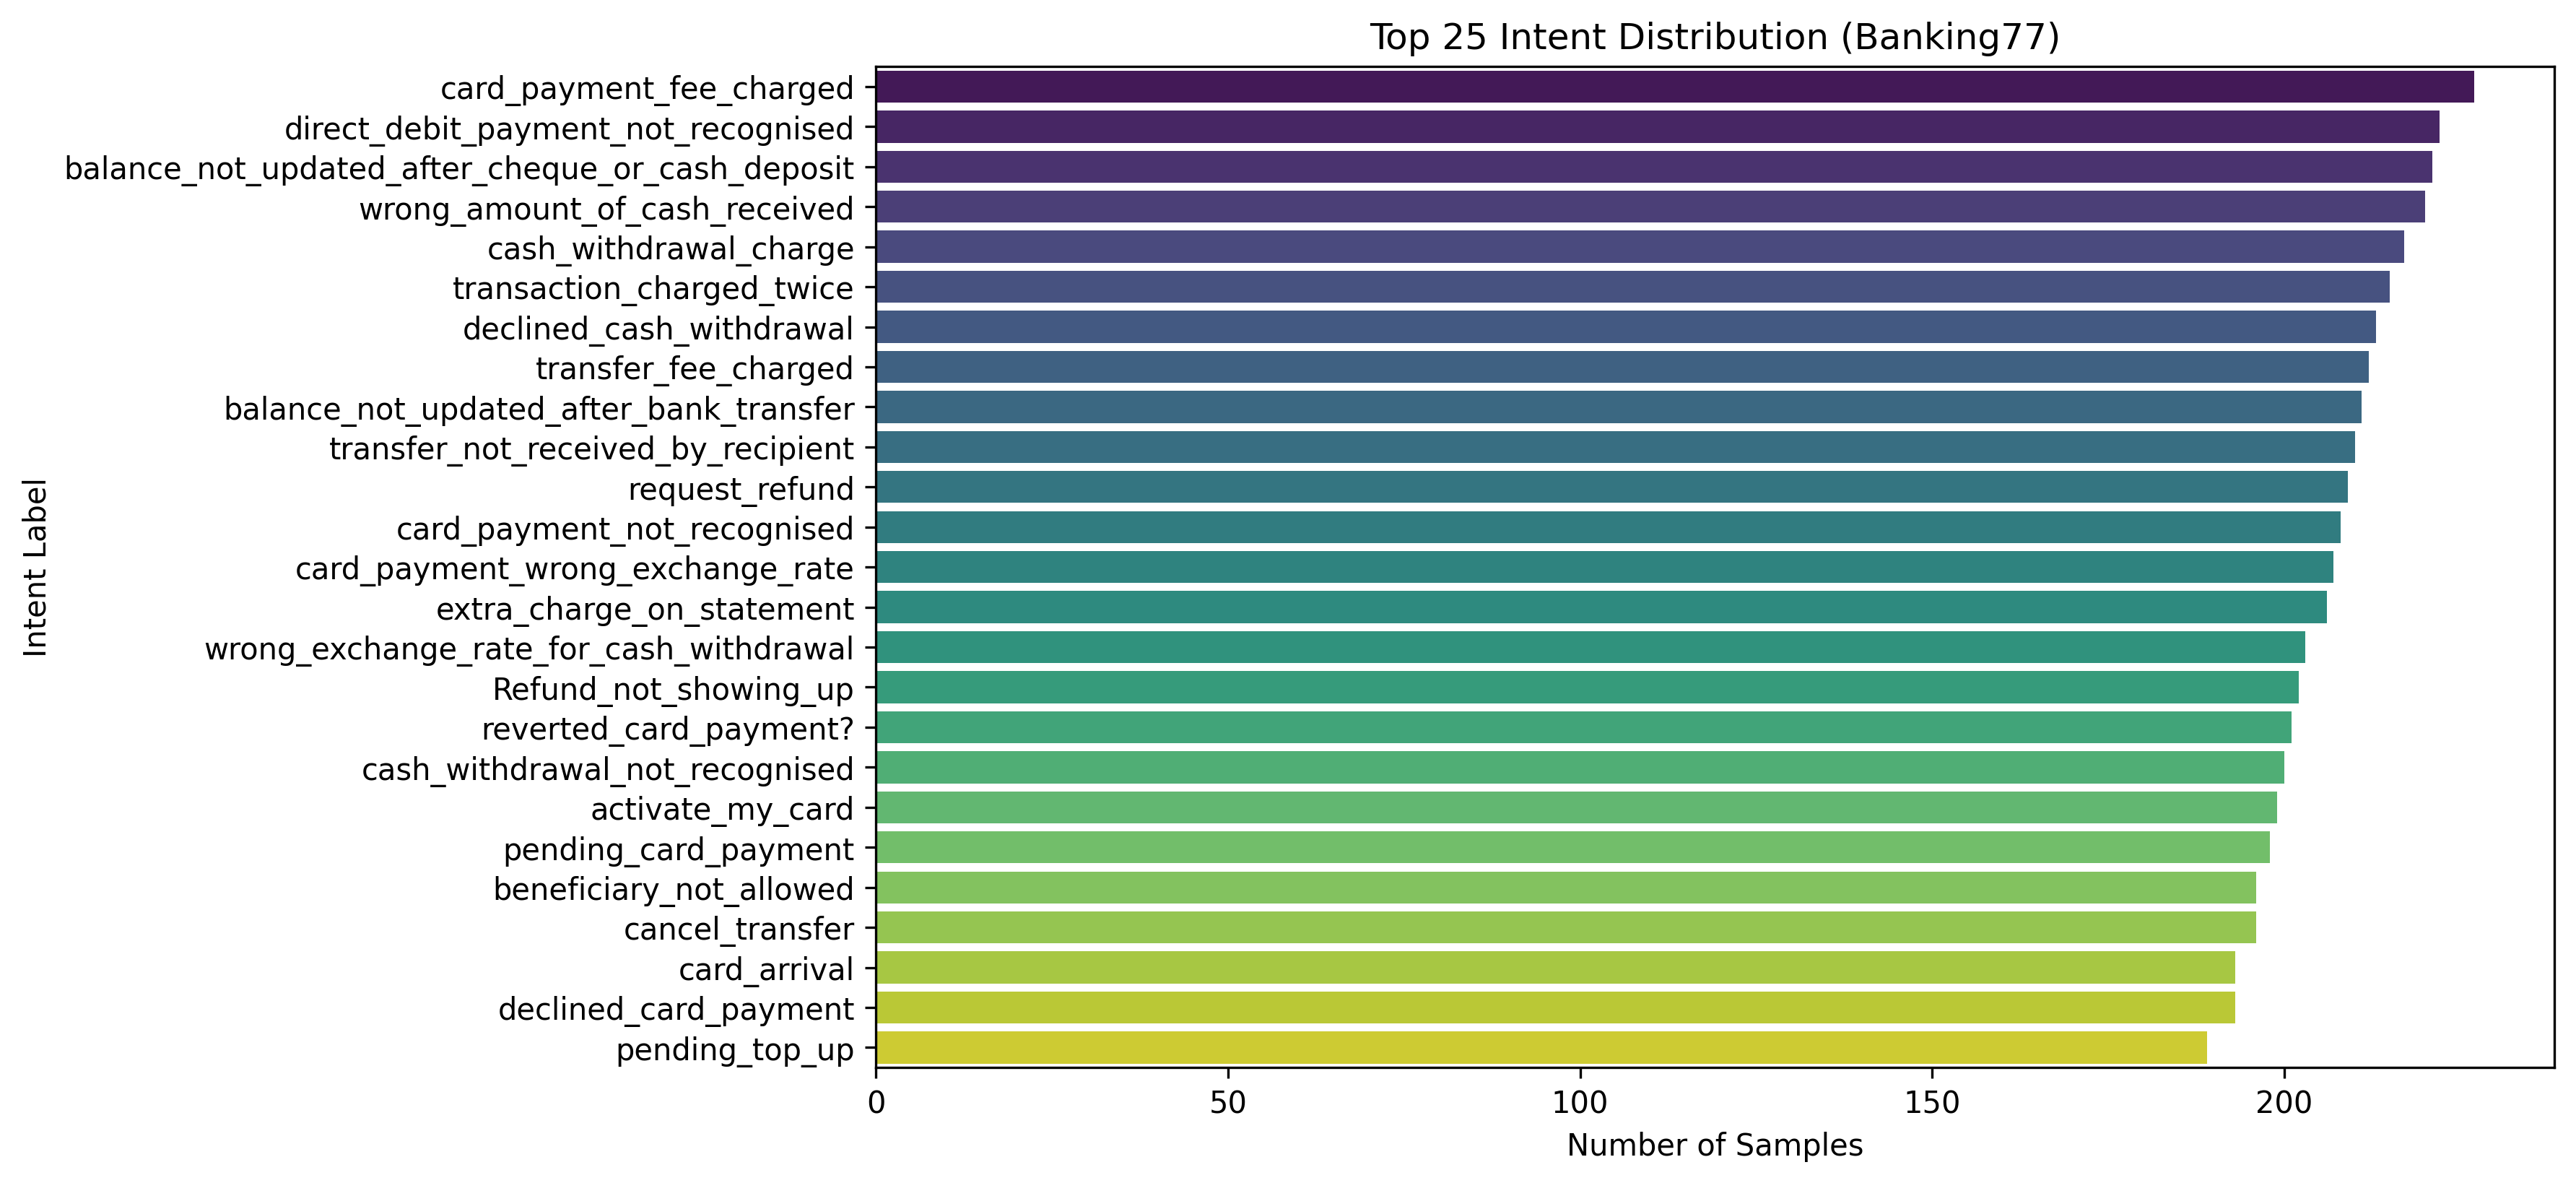

In [5]:
display.Image(filename=str(REPO_ROOT / "outputs" / "eda" / "plots" / "intent_distribution.png"))

### C. Top 20 Most Frequent Words

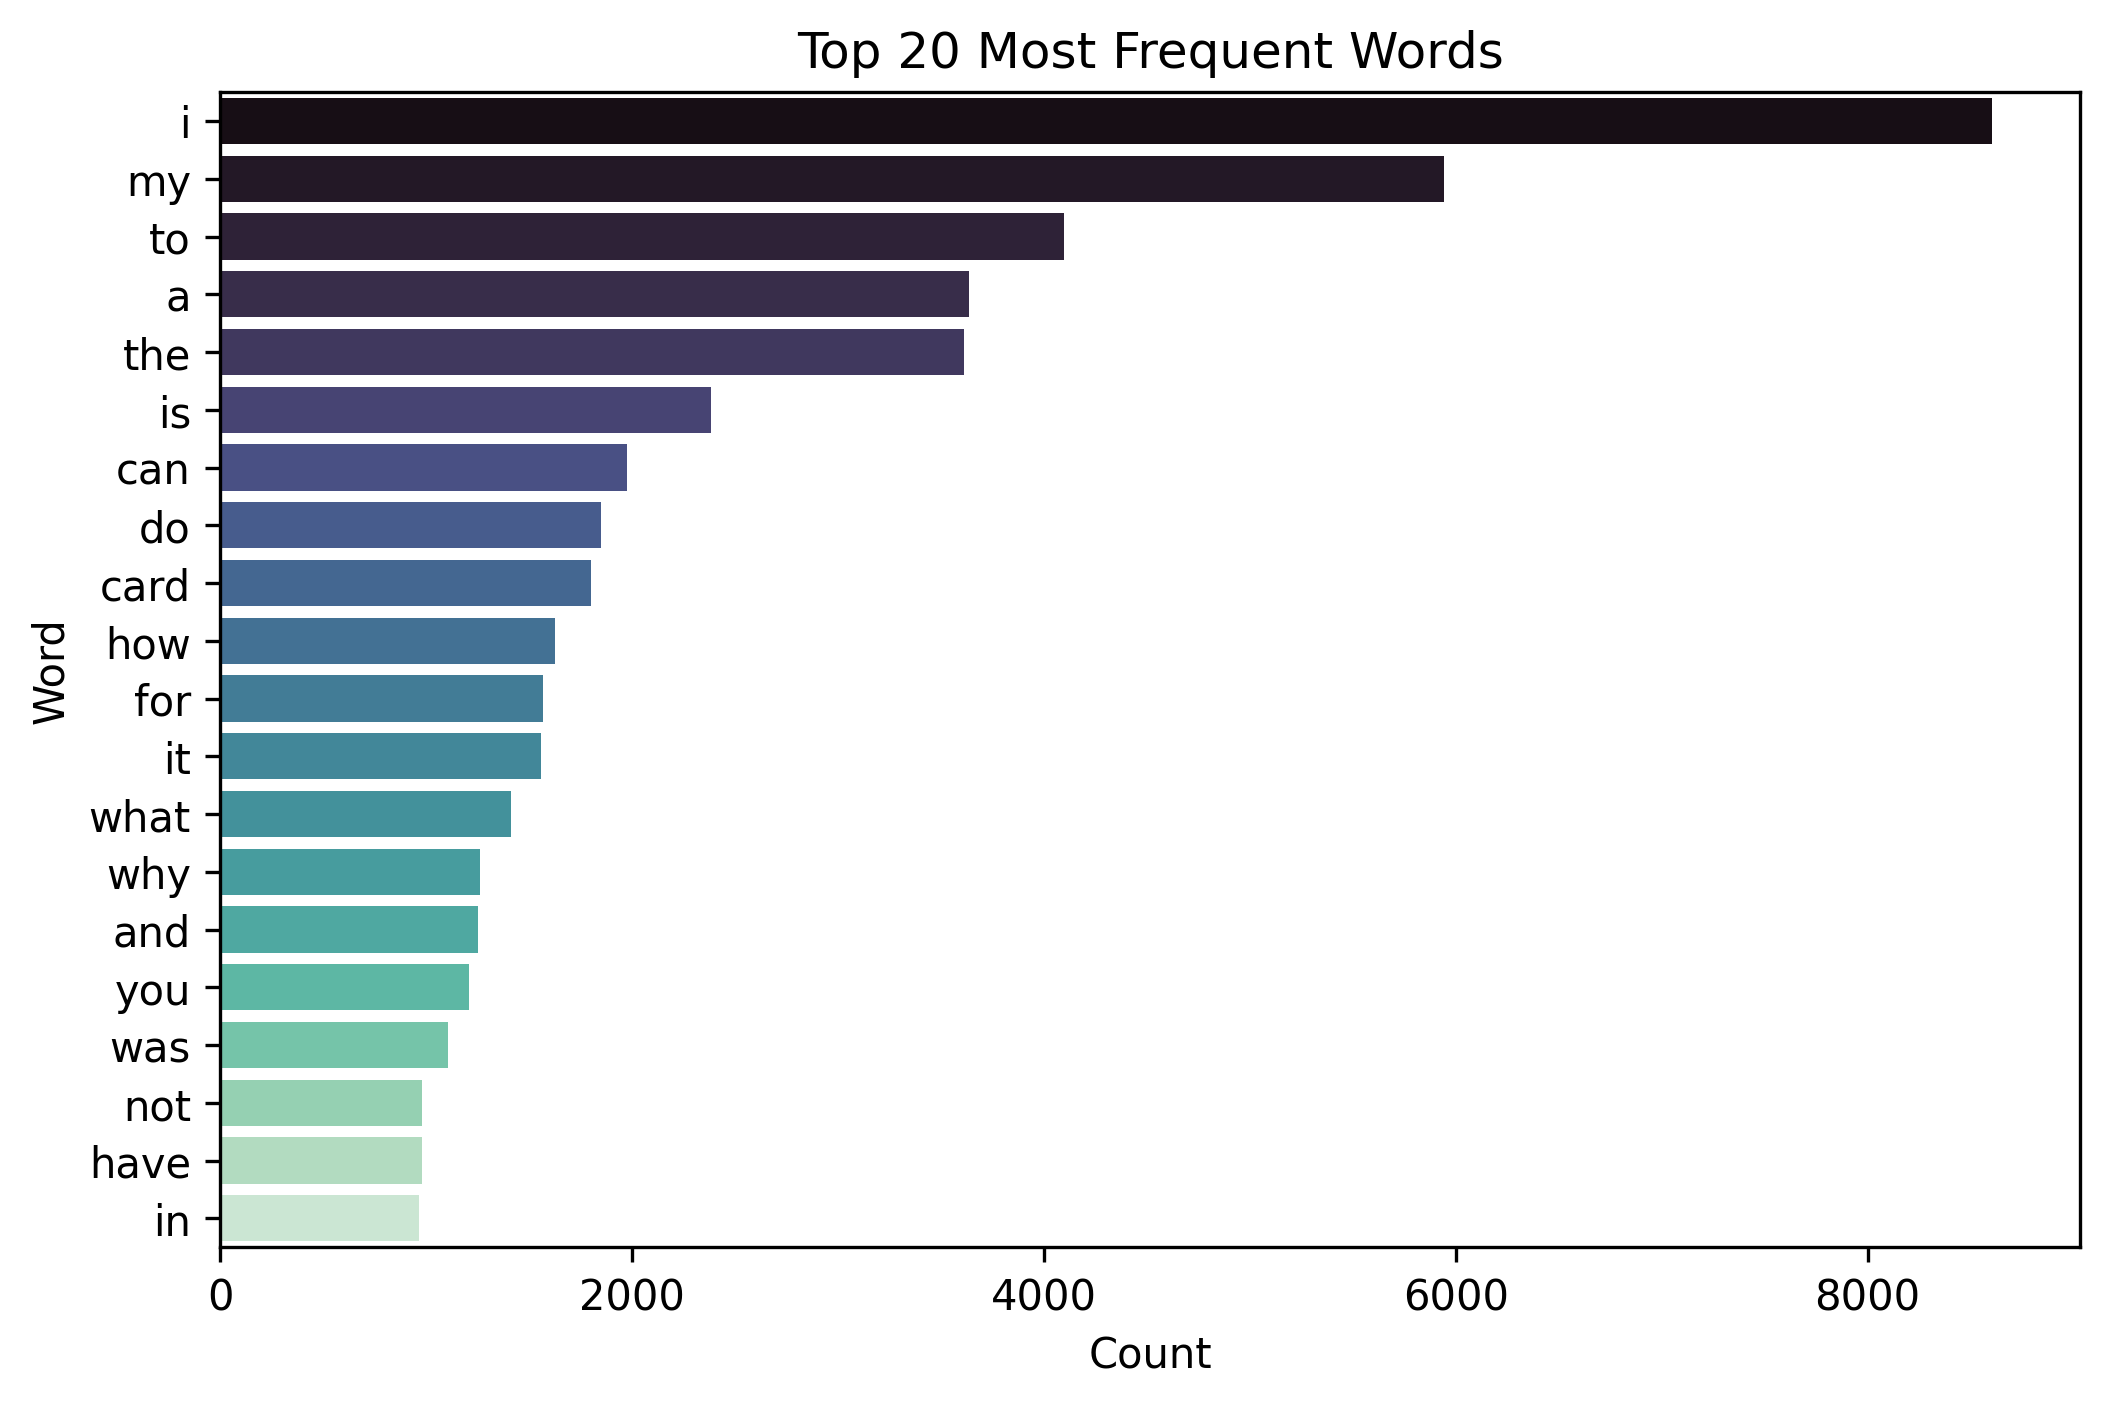

In [6]:
display.Image(filename=str(REPO_ROOT / "outputs" / "eda" / "plots" / "top_words.png"))

## 4. Review Tabular Summaries

Load intent frequency tables and rare classes.

In [7]:
freq_df = pd.read_csv(REPO_ROOT / "outputs" / "eda" / "tables" / "intent_frequencies.csv")
print("=== Top 10 Intent Frequencies ===")
print(freq_df.head(10))

=== Top 10 Intent Frequencies ===
                                             intent  total_count  train_count  \
0                          card_payment_fee_charged          227          182   
1               direct_debit_payment_not_recognised          222          178   
2  balance_not_updated_after_cheque_or_cash_deposit          221          177   
3                     wrong_amount_of_cash_received          220          176   
4                            cash_withdrawal_charge          217          174   
5                         transaction_charged_twice          215          172   
6                          declined_cash_withdrawal          213          170   
7                              transfer_fee_charged          212          170   
8           balance_not_updated_after_bank_transfer          211          169   
9                transfer_not_received_by_recipient          210          168   

   percentage  
0    1.736935  
1    1.698676  
2    1.691025  
3    1.683

In [8]:
rare_df = pd.read_csv(REPO_ROOT / "outputs" / "eda" / "tables" / "rare_intents.csv")
print(f"\n=== Rare Intents (Total Samples < 100, Count={len(rare_df)}) ===")
print(rare_df.head(15))


=== Rare Intents (Total Samples < 100, Count=3) ===
                     intent  total_count  train_count  percentage
0           card_acceptance           99           79    0.757518
1  virtual_card_not_working           81           65    0.619787
2   contactless_not_working           75           60    0.573877


In [9]:
# Export Phase Manifest
from src.api.app import get_git_commit
from src.utils.artifacts import save_yaml

manifest = {
    "phase": "02_EDA_Banking77",
    "total_rows": summary["total_rows"],
    "train_rows": summary["train_rows"],
    "val_rows": summary["val_rows"],
    "test_rows": summary["test_rows"],
    "unique_classes": summary["unique_classes"],
    "rare_classes_count": summary["rare_classes_count"],
    "vocabulary_size": summary["vocabulary_size"],
    "git_commit": get_git_commit(),
}
save_yaml(manifest, REPO_ROOT / "outputs" / "manifests" / "phase_02_eda.yaml")
print("YAML manifest saved successfully:")
print(manifest)

[07/13/26 20:27:49] INFO     Loading faiss with AVX2 support.

                    INFO     Could not load library with AVX2 support due to:                                      
                             ModuleNotFoundError("No module named 'faiss.swigfaiss_avx2'")

                    INFO     Loading faiss.

                    INFO     Successfully loaded faiss.

[07/13/26 20:27:50] INFO     Saving YAML artifact to:                                                              
                             C:\Users\gunav\Downloads\SupportAI\outputs\manifests\phase_02_eda.yaml

YAML manifest saved successfully:
{'phase': '02_EDA_Banking77', 'total_rows': 13069, 'train_rows': 10458, 'val_rows': 1309, 'test_rows': 1302, 'unique_classes': 77, 'rare_classes_count': 3, 'vocabulary_size': 4154, 'git_commit': 'ef9a0498221c5c43373fcf9e951987614174868f'}
